# 09 — Secondary Impact-Label Classification Analysis

## Purpose

This notebook adds a **small, secondary modeling experiment** using the existing
three-level `impact_label` as the prediction target:

1. `trip_changing`
2. `requires_preparation`
3. `informational_minimal_impact`

The completed six-category `primary_label` analysis remains the project's primary
task because it predicts what aspect of a visit is affected. This notebook
evaluates the complementary question of *how much the alert may alter a visitor's
plans*.

## Design choices

- Reuses the finalized 300-alert gold-standard dataset.
- Preserves the original held-out-park and mixed-park splits.
- Compares a majority baseline, TF-IDF logistic regression, and the previously
  selected `all-MiniLM-L6-v2` sentence-embedding approach.
- Uses Macro F1 as the main metric because the three impact classes are imbalanced.
- Adds park-grouped cross-validation as a robustness check.
- Treats this analysis as secondary and exploratory, particularly because the
  fixed held-out test set contains very few informational/minimal-impact examples.

## 1. Install the sentence-transformer dependency

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("sentence_transformers") is None:
    print("Installing sentence-transformers...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"]
    )
else:
    print("sentence-transformers is already installed.")

sentence-transformers is already installed.


## 2. Imports, labels, and reproducibility settings

In [2]:
from pathlib import Path
import json
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

IMPACT_LABELS = [
    "trip_changing",
    "requires_preparation",
    "informational_minimal_impact",
]

DISPLAY_LABELS = {
    "trip_changing": "Trip-changing",
    "requires_preparation": "Requires preparation",
    "informational_minimal_impact": "Informational / minimal impact",
}

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
C_VALUES = [0.1, 0.3, 1.0, 3.0, 10.0]

preferred_output_dirs = [
    Path("/content/nps_impact_outputs"),
    Path("/mnt/data/nps_impact_outputs"),
    Path("nps_impact_outputs"),
]

OUTPUT_DIR = None
for candidate in preferred_output_dirs:
    try:
        candidate.mkdir(parents=True, exist_ok=True)
        OUTPUT_DIR = candidate
        break
    except (PermissionError, OSError):
        continue

if OUTPUT_DIR is None:
    raise PermissionError("Could not create an output directory.")

print("Ready.")
print("Outputs will be saved to:", OUTPUT_DIR.resolve())

Ready.
Outputs will be saved to: /content/nps_impact_outputs


## 3. Locate and load the finalized modeling dataset



In [3]:
SEARCH_DIRS = [
    Path("/content"),
    Path("/mnt/data"),
    Path("."),
]

POSSIBLE_NAMES = [
    "nps_gold_modeling_dataset_with_splits.csv",
    "nps_gold_modeling_dataset_with_splits (1).csv",
    "nps_gold_modeling_dataset_with_splits(1).csv",
]

def find_modeling_file():
    for directory in SEARCH_DIRS:
        for filename in POSSIBLE_NAMES:
            candidate = directory / filename
            if candidate.exists():
                return candidate

        if directory.exists():
            matches = sorted(
                directory.rglob("nps_gold_modeling_dataset_with_splits*.csv")
            )
            if matches:
                return matches[-1]

    try:
        from google.colab import files

        print("Upload nps_gold_modeling_dataset_with_splits.csv")
        uploaded = files.upload()
        if uploaded:
            uploaded_name = next(iter(uploaded))
            return Path("/content") / uploaded_name
    except ImportError:
        pass

    raise FileNotFoundError(
        "Could not find the finalized modeling CSV. Place it in the same folder "
        "as this notebook, /content, or /mnt/data."
    )

MODELING_PATH = find_modeling_file()
modeling_df = pd.read_csv(MODELING_PATH)

print("Loaded:", MODELING_PATH)
print("Shape:", modeling_df.shape)
display(modeling_df.head())

Loaded: /content/nps_gold_modeling_dataset_with_splits.csv
Shape: (300, 14)


,id,parkCode,fullName,category,title,description,combined_text_raw,normalized_text_modeling,primary_label,secondary_label,impact_label,heldout_park_split,mixed_park_split,source_stage
0,C3706E5C-8B0E-4DA2-B088-B2CB8A3F5B91,colm,Colorado National Monument,Information,6/16/26 - 8/6/26 Roadside Vegetation Removal -...,Vegetation crews will be removing encroaching ...,6/16/26 - 8/6/26 Roadside Vegetation Removal -...,6/16/26 - 8/6/26 roadside vegetation removal -...,road_parking_transportation,construction_maintenance_general,requires_preparation,train,test,expansion_candidate
1,FA5B5B82-2AFE-4785-8976-A6FE71BD9181,bicr,Birmingham Civil Rights National Monument,Park Closure,A.G Gaston Motel Closed for Construction,The 1954 wing of the A.G. Gaston Motel is clos...,A.G Gaston Motel Closed for Construction The 1...,a.g gaston motel closed for construction the 1...,facility_water_campground_service,construction_maintenance_general,trip_changing,test,validation,completed_pilot
2,587FA8D1-FD28-4A77-A5B8-6ED5CC62BAA0,biso,Big South Fork National River & Recreation Area,Information,Access to Big South Fork’s Scenic O&W Road Blo...,Road access to O&W Road was blocked by order o...,Access to Big South Fork’s Scenic O&W Road Blo...,access to big south fork’s scenic o&w road blo...,road_parking_transportation,NaN,trip_changing,test,validation,expansion_candidate
3,61BCC320-4652-4ED1-99BD-D8503964F911,asis,Assateague Island National Seashore,Information,Administrative Closure of Areas due to Nesting...,Effective 4/2/26: The closure includes the fol...,Administrative Closure of Areas due to Nesting...,administrative closure of areas due to nesting...,wildlife_hazard_or_restriction,trail_or_area_access,trip_changing,train,train,expansion_candidate
4,77FB8896-4A62-4B7C-971A-182AE991288B,npsa,National Park of American Samoa,Park Closure,Alava Trail Closure,The Mount Alava trail and Fatifati trail from ...,Alava Trail Closure The Mount Alava trail and ...,alava trail closure the mount alava trail and ...,trail_or_area_access,NaN,trip_changing,train,validation,completed_pilot


## 4. Validate the impact target, text, and original split assignments

In [4]:
required_columns = {
    "id",
    "parkCode",
    "title",
    "description",
    "primary_label",
    "impact_label",
    "heldout_park_split",
    "mixed_park_split",
}

missing_columns = required_columns - set(modeling_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

modeling_df["title"] = modeling_df["title"].fillna("").astype(str)
modeling_df["description"] = modeling_df["description"].fillna("").astype(str)
modeling_df["impact_label"] = modeling_df["impact_label"].astype(str).str.strip()

modeling_df["text_title_description"] = (
    modeling_df["title"].str.strip()
    + " "
    + modeling_df["description"].str.strip()
).str.strip()

if modeling_df["text_title_description"].eq("").any():
    raise ValueError("At least one modeling record has empty title + description text.")

invalid_labels = set(modeling_df["impact_label"]) - set(IMPACT_LABELS)
if invalid_labels:
    raise ValueError(f"Unexpected impact labels: {sorted(invalid_labels)}")

for split_column in ["heldout_park_split", "mixed_park_split"]:
    invalid_splits = set(modeling_df[split_column]) - {
        "train", "validation", "test"
    }
    if invalid_splits:
        raise ValueError(
            f"Unexpected values in {split_column}: {sorted(invalid_splits)}"
        )

# The primary held-out design requires every park to occur in only one partition.
heldout_park_partitions = (
    modeling_df.groupby("parkCode")["heldout_park_split"].nunique()
)
assert heldout_park_partitions.max() == 1, (
    "At least one park appears in multiple held-out partitions."
)

print("Records:", len(modeling_df))
print("Unique parks:", modeling_df["parkCode"].nunique())
print("Unique IDs:", modeling_df["id"].nunique())

print("\nOverall impact-label counts:")
display(
    modeling_df["impact_label"]
    .value_counts()
    .reindex(IMPACT_LABELS, fill_value=0)
    .rename("count")
    .to_frame()
)

for split_column, title in [
    ("heldout_park_split", "Held-out-park split"),
    ("mixed_park_split", "Mixed-park split"),
]:
    print(f"\n{title}:")
    display(
        pd.crosstab(
            modeling_df["impact_label"],
            modeling_df[split_column],
        )
        .reindex(IMPACT_LABELS, fill_value=0)
        .reindex(columns=["train", "validation", "test"], fill_value=0)
    )

Records: 300
Unique parks: 199
Unique IDs: 300

Overall impact-label counts:


,count
impact_label,
trip_changing,99
requires_preparation,169
informational_minimal_impact,32



Held-out-park split:


heldout_park_split,train,validation,test
impact_label,,,
trip_changing,66,17,16
requires_preparation,123,20,26
informational_minimal_impact,22,7,3



Mixed-park split:


mixed_park_split,train,validation,test
impact_label,,,
trip_changing,65,20,14
requires_preparation,121,22,26
informational_minimal_impact,24,3,5


### Important fixed-test limitation

The original split was created before this secondary target became central. Retaining
it protects against changing the test set after seeing results, but the held-out test
contains only a few `informational_minimal_impact` examples.

## 5. Evaluation and modeling helpers

In [5]:
def metric_summary(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=IMPACT_LABELS,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=IMPACT_LABELS,
            average="weighted",
            zero_division=0,
        ),
    }


def per_class_metrics(y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=IMPACT_LABELS,
        zero_division=0,
    )

    return pd.DataFrame({
        "impact_label": IMPACT_LABELS,
        "display_label": [DISPLAY_LABELS[label] for label in IMPACT_LABELS],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })


def plot_confusion(y_true, y_pred, title):
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=IMPACT_LABELS,
    )

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    confusion_display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[DISPLAY_LABELS[label] for label in IMPACT_LABELS],
    )
    confusion_display.plot(
        ax=ax,
        xticks_rotation=25,
        values_format="d",
        colorbar=False,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig


def evaluate_predictions(
    frame,
    y_pred,
    model_name,
    evaluation_setting,
    partition,
):
    y_true = frame["impact_label"]
    summary = metric_summary(y_true, y_pred)
    summary.update({
        "model": model_name,
        "evaluation_setting": evaluation_setting,
        "partition": partition,
        "n": len(frame),
    })

    class_table = per_class_metrics(y_true, y_pred)
    class_table["model"] = model_name
    class_table["evaluation_setting"] = evaluation_setting
    class_table["partition"] = partition

    prediction_table = frame[
        [
            "id",
            "parkCode",
            "title",
            "description",
            "primary_label",
            "impact_label",
        ]
    ].copy()
    prediction_table["predicted_impact_label"] = y_pred
    prediction_table["correct"] = (
        prediction_table["impact_label"]
        == prediction_table["predicted_impact_label"]
    )
    prediction_table["model"] = model_name
    prediction_table["evaluation_setting"] = evaluation_setting
    prediction_table["partition"] = partition

    return summary, class_table, prediction_table


def make_tfidf_model():
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                stop_words="english",
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ])


def make_embedding_classifier(C=1.0):
    return Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                C=C,
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ])

## 6. Majority and TF-IDF baselines

The TF-IDF specification matches the completed baseline notebook as closely as
possible; only the target changes from `primary_label` to `impact_label`.

In [6]:
all_metric_rows = []
all_class_metric_tables = []
all_prediction_tables = []
fitted_baseline_models = {}

for split_column, evaluation_setting in [
    ("heldout_park_split", "Held-out parks"),
    ("mixed_park_split", "Mixed parks"),
]:
    train_df = modeling_df.loc[
        modeling_df[split_column].eq("train")
    ].copy()

    models = {
        "Majority baseline": DummyClassifier(
            strategy="most_frequent",
            random_state=RANDOM_STATE,
        ),
        "TF-IDF + logistic regression": make_tfidf_model(),
    }

    for model_name, model in models.items():
        model.fit(
            train_df["text_title_description"],
            train_df["impact_label"],
        )
        fitted_baseline_models[(evaluation_setting, model_name)] = model

        for partition in ["validation", "test"]:
            partition_df = modeling_df.loc[
                modeling_df[split_column].eq(partition)
            ].copy()

            y_pred = model.predict(
                partition_df["text_title_description"]
            )

            summary, class_table, prediction_table = evaluate_predictions(
                frame=partition_df,
                y_pred=y_pred,
                model_name=model_name,
                evaluation_setting=evaluation_setting,
                partition=partition,
            )

            all_metric_rows.append(summary)
            all_class_metric_tables.append(class_table)
            all_prediction_tables.append(prediction_table)

baseline_metrics_df = pd.DataFrame(all_metric_rows)
baseline_class_metrics_df = pd.concat(
    all_class_metric_tables,
    ignore_index=True,
)
baseline_predictions_df = pd.concat(
    all_prediction_tables,
    ignore_index=True,
)

print("Baseline validation and test results:")
display(
    baseline_metrics_df.sort_values(
        ["partition", "evaluation_setting", "macro_f1"],
        ascending=[True, True, False],
    ).reset_index(drop=True).round(3)
)

Baseline validation and test results:


,accuracy,macro_f1,weighted_f1,model,evaluation_setting,partition,n
0,0.756,0.524,0.739,TF-IDF + logistic regression,Held-out parks,test,45
1,0.578,0.244,0.423,Majority baseline,Held-out parks,test,45
2,0.778,0.643,0.760,TF-IDF + logistic regression,Mixed parks,test,45
3,0.578,0.244,0.423,Majority baseline,Mixed parks,test,45
4,0.932,0.882,0.924,TF-IDF + logistic regression,Held-out parks,validation,44
5,0.455,0.208,0.284,Majority baseline,Held-out parks,validation,44
6,0.800,0.681,0.792,TF-IDF + logistic regression,Mixed parks,validation,45
7,0.489,0.219,0.321,Majority baseline,Mixed parks,validation,45


## 7. Load the selected sentence-transformer and encode alert text

In [7]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

print("Loaded:", EMBEDDING_MODEL_NAME)
print(
    "Embedding dimension:",
    embedding_model.get_sentence_embedding_dimension(),
)

embeddings = embedding_model.encode(
    modeling_df["text_title_description"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
)

embeddings = np.asarray(embeddings)
print("Embedding matrix shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Embedding matrix shape: (300, 384)


## 8. Select logistic-regression regularization using held-out-park validation

This selection uses only the original held-out training and validation partitions.
The fixed held-out test set remains untouched until the final evaluation.

In [8]:
heldout_train_mask = (
    modeling_df["heldout_park_split"].eq("train").to_numpy()
)
heldout_validation_mask = (
    modeling_df["heldout_park_split"].eq("validation").to_numpy()
)

y_heldout_train = modeling_df.loc[
    modeling_df["heldout_park_split"].eq("train"),
    "impact_label",
]
y_heldout_validation = modeling_df.loc[
    modeling_df["heldout_park_split"].eq("validation"),
    "impact_label",
]

validation_rows = []

for C in C_VALUES:
    model = make_embedding_classifier(C=C)
    model.fit(
        embeddings[heldout_train_mask],
        y_heldout_train,
    )

    validation_pred = model.predict(
        embeddings[heldout_validation_mask]
    )
    metrics = metric_summary(
        y_heldout_validation,
        validation_pred,
    )

    validation_rows.append({
        "C": C,
        "validation_accuracy": metrics["accuracy"],
        "validation_macro_f1": metrics["macro_f1"],
        "validation_weighted_f1": metrics["weighted_f1"],
    })

embedding_validation_df = (
    pd.DataFrame(validation_rows)
    .sort_values(
        ["validation_macro_f1", "validation_weighted_f1"],
        ascending=False,
    )
    .reset_index(drop=True)
)

best_C = float(embedding_validation_df.loc[0, "C"])

display(embedding_validation_df.round(3))
print("Selected C:", best_C)

,C,validation_accuracy,validation_macro_f1,validation_weighted_f1
0,10.0,0.818,0.763,0.806
1,0.1,0.818,0.724,0.796
2,3.0,0.795,0.709,0.777
3,0.3,0.795,0.705,0.774
4,1.0,0.795,0.705,0.774


Selected C: 10.0


## 9. Evaluate the selected sentence-embedding classifier

In [9]:
embedding_metric_rows = []
embedding_class_tables = []
embedding_prediction_tables = []
fitted_embedding_models = {}

for split_column, evaluation_setting in [
    ("heldout_park_split", "Held-out parks"),
    ("mixed_park_split", "Mixed parks"),
]:
    train_mask = modeling_df[split_column].eq("train").to_numpy()
    y_train = modeling_df.loc[
        modeling_df[split_column].eq("train"),
        "impact_label",
    ]

    model = make_embedding_classifier(C=best_C)
    model.fit(embeddings[train_mask], y_train)
    fitted_embedding_models[evaluation_setting] = model

    for partition in ["validation", "test"]:
        partition_mask = modeling_df[split_column].eq(partition).to_numpy()
        partition_df = modeling_df.loc[
            modeling_df[split_column].eq(partition)
        ].copy()

        y_pred = model.predict(embeddings[partition_mask])

        summary, class_table, prediction_table = evaluate_predictions(
            frame=partition_df,
            y_pred=y_pred,
            model_name="Sentence embeddings + logistic regression",
            evaluation_setting=evaluation_setting,
            partition=partition,
        )

        embedding_metric_rows.append(summary)
        embedding_class_tables.append(class_table)
        embedding_prediction_tables.append(prediction_table)

embedding_metrics_df = pd.DataFrame(embedding_metric_rows)
embedding_class_metrics_df = pd.concat(
    embedding_class_tables,
    ignore_index=True,
)
embedding_predictions_df = pd.concat(
    embedding_prediction_tables,
    ignore_index=True,
)

print("Sentence-embedding validation and test results:")
display(
    embedding_metrics_df.sort_values(
        ["partition", "evaluation_setting"],
    ).reset_index(drop=True).round(3)
)

Sentence-embedding validation and test results:


,accuracy,macro_f1,weighted_f1,model,evaluation_setting,partition,n
0,0.733,0.619,0.733,Sentence embeddings + logistic regression,Held-out parks,test,45
1,0.778,0.698,0.786,Sentence embeddings + logistic regression,Mixed parks,test,45
2,0.818,0.763,0.806,Sentence embeddings + logistic regression,Held-out parks,validation,44
3,0.733,0.650,0.750,Sentence embeddings + logistic regression,Mixed parks,validation,45


## 10. Consolidated model comparison

In [10]:
all_metrics_df = pd.concat(
    [
        baseline_metrics_df,
        embedding_metrics_df,
    ],
    ignore_index=True,
)

all_class_metrics_df = pd.concat(
    [
        baseline_class_metrics_df,
        embedding_class_metrics_df,
    ],
    ignore_index=True,
)

all_predictions_df = pd.concat(
    [
        baseline_predictions_df,
        embedding_predictions_df,
    ],
    ignore_index=True,
)

test_metrics_df = all_metrics_df.loc[
    all_metrics_df["partition"].eq("test")
].copy()

final_comparison_table = (
    test_metrics_df
    .pivot_table(
        index="model",
        columns="evaluation_setting",
        values=["accuracy", "macro_f1", "weighted_f1"],
        aggfunc="first",
    )
    .round(3)
)

print("Test-set comparison:")
display(final_comparison_table)

generalization_gap_df = (
    test_metrics_df
    .pivot_table(
        index="model",
        columns="evaluation_setting",
        values="macro_f1",
        aggfunc="first",
    )
    .rename_axis(None, axis=1)
    .reset_index()
)

generalization_gap_df["generalization_gap"] = (
    generalization_gap_df["Mixed parks"]
    - generalization_gap_df["Held-out parks"]
)

generalization_gap_df = generalization_gap_df.sort_values(
    "Held-out parks",
    ascending=False,
).reset_index(drop=True)

print("\nMacro F1 generalization gap:")
display(generalization_gap_df.round(3))

Test-set comparison:


accuracy              \
evaluation_setting                        Held-out parks Mixed parks   
model                                                                  
Majority baseline                                  0.578       0.578   
Sentence embeddings + logistic regression          0.733       0.778   
TF-IDF + logistic regression                       0.756       0.778   

                                                macro_f1              \
evaluation_setting                        Held-out parks Mixed parks   
model                                                                  
Majority baseline                                  0.244       0.244   
Sentence embeddings + logistic regression          0.619       0.698   
TF-IDF + logistic regression                       0.524       0.643   

                                             weighted_f1              
evaluation_setting                        Held-out parks Mixed parks  
model                                                                 
Majority baseline                                  0.423       0.423  
Sentence embeddings + logistic regression          0.733       0.786  
TF-IDF + logistic regression                       0.739       0.760


Macro F1 generalization gap:


,model,Held-out parks,Mixed parks,generalization_gap
0,Sentence embeddings + logistic regression,0.619,0.698,0.079
1,TF-IDF + logistic regression,0.524,0.643,0.119
2,Majority baseline,0.244,0.244,0.000


## 11. Test-performance figure

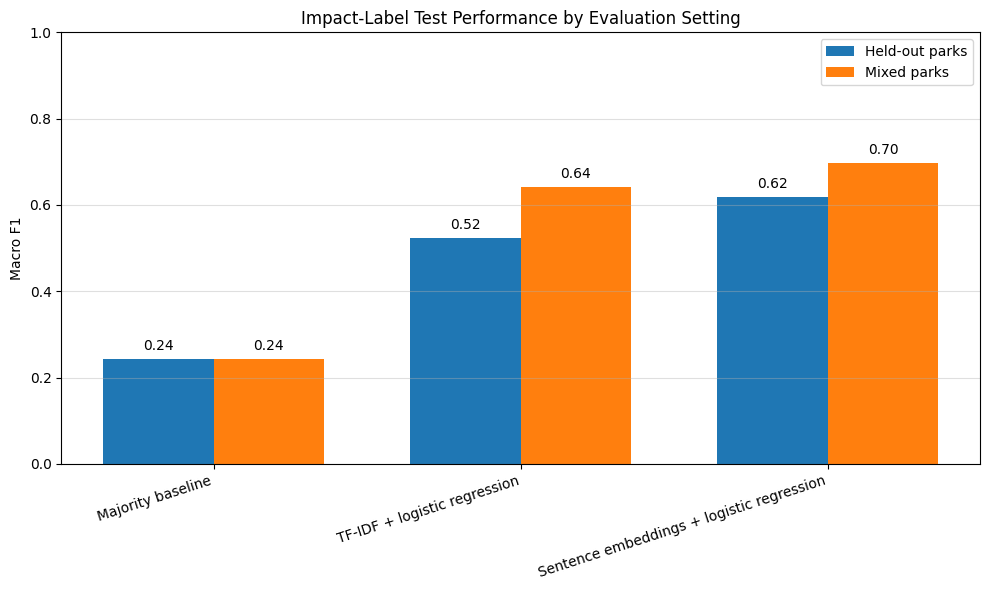

In [11]:
model_order = [
    "Majority baseline",
    "TF-IDF + logistic regression",
    "Sentence embeddings + logistic regression",
]

x = np.arange(len(model_order))
width = 0.36

heldout_values = [
    test_metrics_df.loc[
        test_metrics_df["model"].eq(model)
        & test_metrics_df["evaluation_setting"].eq("Held-out parks"),
        "macro_f1",
    ].iloc[0]
    for model in model_order
]

mixed_values = [
    test_metrics_df.loc[
        test_metrics_df["model"].eq(model)
        & test_metrics_df["evaluation_setting"].eq("Mixed parks"),
        "macro_f1",
    ].iloc[0]
    for model in model_order
]

fig_model_comparison, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x - width / 2,
    heldout_values,
    width,
    label="Held-out parks",
)
ax.bar(
    x + width / 2,
    mixed_values,
    width,
    label="Mixed parks",
)

ax.set_ylabel("Macro F1")
ax.set_title("Impact-Label Test Performance by Evaluation Setting")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=18, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", linewidth=0.8, alpha=0.4)

for index, value in enumerate(heldout_values):
    ax.text(
        index - width / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
    )

for index, value in enumerate(mixed_values):
    ax.text(
        index + width / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
    )

plt.tight_layout()
plt.show()

## 12. Selected model: held-out confusion matrix and per-class results

The held-out-park setting is the primary evaluation because it tests transfer to
parks that were not represented during training.

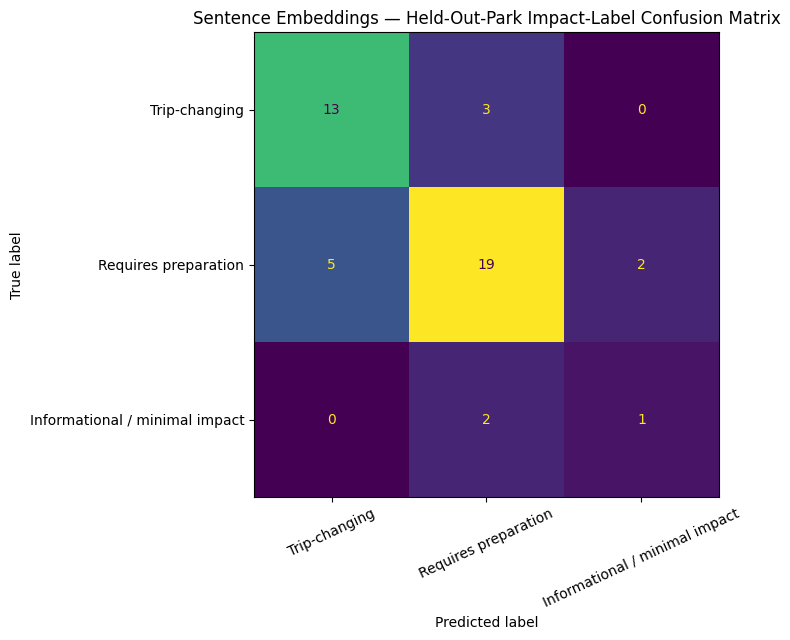

,impact_label,display_label,precision,recall,f1,support
0,trip_changing,Trip-changing,0.722,0.812,0.765,16
1,requires_preparation,Requires preparation,0.792,0.731,0.760,26
2,informational_minimal_impact,Informational / minimal impact,0.333,0.333,0.333,3


In [12]:
selected_model_name = "Sentence embeddings + logistic regression"

selected_heldout_predictions = embedding_predictions_df.loc[
    embedding_predictions_df["evaluation_setting"].eq("Held-out parks")
    & embedding_predictions_df["partition"].eq("test")
].copy()

fig_confusion = plot_confusion(
    selected_heldout_predictions["impact_label"],
    selected_heldout_predictions["predicted_impact_label"],
    title=(
        "Sentence Embeddings — Held-Out-Park "
        "Impact-Label Confusion Matrix"
    ),
)

selected_heldout_class_metrics = embedding_class_metrics_df.loc[
    embedding_class_metrics_df["evaluation_setting"].eq("Held-out parks")
    & embedding_class_metrics_df["partition"].eq("test")
][
    [
        "impact_label",
        "display_label",
        "precision",
        "recall",
        "f1",
        "support",
    ]
].reset_index(drop=True)

display(selected_heldout_class_metrics.round(3))

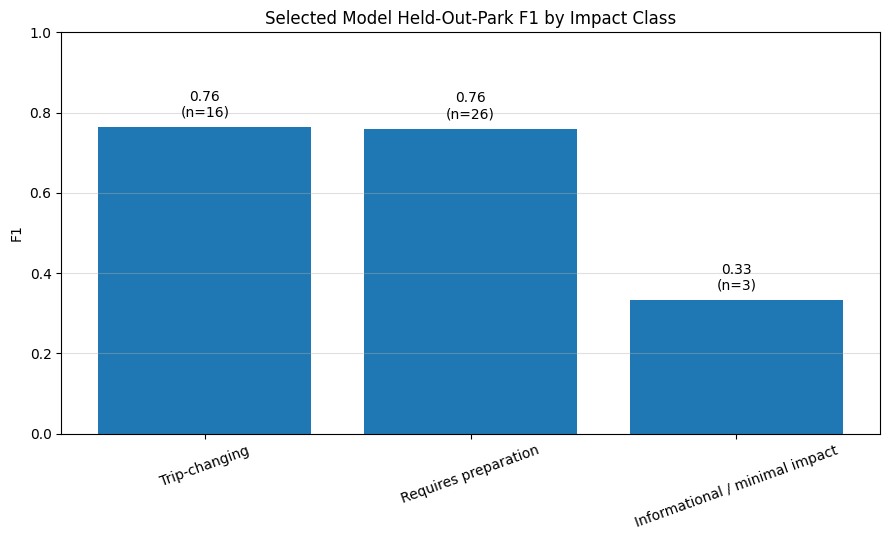

In [13]:
fig_per_class, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(
    selected_heldout_class_metrics["display_label"],
    selected_heldout_class_metrics["f1"],
)

ax.set_ylabel("F1")
ax.set_title(
    "Selected Model Held-Out-Park F1 by Impact Class"
)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", linewidth=0.8, alpha=0.4)

for index, row in selected_heldout_class_metrics.iterrows():
    ax.text(
        index,
        row["f1"] + 0.025,
        f'{row["f1"]:.2f}\n(n={int(row["support"])})',
        ha="center",
    )

plt.tight_layout()
plt.show()

## 13. Held-out error review

In [14]:
selected_heldout_errors = selected_heldout_predictions.loc[
    ~selected_heldout_predictions["correct"]
].copy()

selected_heldout_errors["true_display"] = (
    selected_heldout_errors["impact_label"].map(DISPLAY_LABELS)
)
selected_heldout_errors["predicted_display"] = (
    selected_heldout_errors["predicted_impact_label"].map(DISPLAY_LABELS)
)

display(
    selected_heldout_errors[
        [
            "parkCode",
            "title",
            "primary_label",
            "true_display",
            "predicted_display",
        ]
    ].reset_index(drop=True)
)

confusion_pairs_df = (
    selected_heldout_errors
    .groupby(["true_display", "predicted_display"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("Most common error directions:")
display(confusion_pairs_df)

,parkCode,title,primary_label,true_display,predicted_display
0,beol,Capacity Restrictions at the Reconstructed Fort,facility_water_campground_service,Requires preparation,Trip-changing
1,edis,Glenmont Heat Advisory,weather_fire_environmental_hazard,Requires preparation,Informational / minimal impact
2,vafo,Isaac Potts House (Washington's Headquarters) ...,facility_water_campground_service,Trip-changing,Requires preparation
3,olym,"Limited Rialto Beach Parking, Mora Rd Construc...",road_parking_transportation,Requires preparation,Trip-changing
4,okci,Museum to Remain Open During Construction,facility_water_campground_service,Requires preparation,Trip-changing
5,till,Ongoing Construction at the Emmett Till Interp...,facility_water_campground_service,Informational / minimal impact,Requires preparation
6,adam,Phone Messaging System Errors,facility_water_campground_service,Requires preparation,Informational / minimal impact
7,beol,Plaza Access to Reconstructed Fort,trail_or_area_access,Requires preparation,Trip-changing
8,jame,Rehabilitation of Colonial Parkway continues w...,road_parking_transportation,Trip-changing,Requires preparation
9,chch,Road Construction Continues on a Section of Br...,road_parking_transportation,Requires preparation,Trip-changing


Most common error directions:


,true_display,predicted_display,count
0,Requires preparation,Trip-changing,5
1,Trip-changing,Requires preparation,3
2,Requires preparation,Informational / minimal impact,2
3,Informational / minimal impact,Requires preparation,2


## 14. Park-grouped cross-validation robustness check

This five-fold analysis keeps all records from the same park in the same fold while
approximately balancing the three impact labels across folds. It does not replace
the original held-out test; it supplements it because the fixed rare-class support
is small.

In [15]:
grouped_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_rows = []

y_all = modeling_df["impact_label"].to_numpy()
groups = modeling_df["parkCode"].to_numpy()

for fold, (train_index, test_index) in enumerate(
    grouped_cv.split(
        embeddings,
        y_all,
        groups=groups,
    ),
    start=1,
):
    model = make_embedding_classifier(C=best_C)
    model.fit(
        embeddings[train_index],
        y_all[train_index],
    )

    y_pred = model.predict(embeddings[test_index])
    metrics = metric_summary(y_all[test_index], y_pred)

    fold_support = (
        pd.Series(y_all[test_index])
        .value_counts()
        .reindex(IMPACT_LABELS, fill_value=0)
    )

    cv_rows.append({
        "fold": fold,
        "n_train": len(train_index),
        "n_test": len(test_index),
        "train_parks": modeling_df.iloc[train_index]["parkCode"].nunique(),
        "test_parks": modeling_df.iloc[test_index]["parkCode"].nunique(),
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "trip_changing_support": int(fold_support["trip_changing"]),
        "requires_preparation_support": int(
            fold_support["requires_preparation"]
        ),
        "informational_minimal_impact_support": int(
            fold_support["informational_minimal_impact"]
        ),
    })

grouped_cv_folds_df = pd.DataFrame(cv_rows)

grouped_cv_summary_df = pd.DataFrame({
    "metric": ["accuracy", "macro_f1", "weighted_f1"],
    "mean": [
        grouped_cv_folds_df["accuracy"].mean(),
        grouped_cv_folds_df["macro_f1"].mean(),
        grouped_cv_folds_df["weighted_f1"].mean(),
    ],
    "standard_deviation": [
        grouped_cv_folds_df["accuracy"].std(ddof=1),
        grouped_cv_folds_df["macro_f1"].std(ddof=1),
        grouped_cv_folds_df["weighted_f1"].std(ddof=1),
    ],
    "minimum": [
        grouped_cv_folds_df["accuracy"].min(),
        grouped_cv_folds_df["macro_f1"].min(),
        grouped_cv_folds_df["weighted_f1"].min(),
    ],
    "maximum": [
        grouped_cv_folds_df["accuracy"].max(),
        grouped_cv_folds_df["macro_f1"].max(),
        grouped_cv_folds_df["weighted_f1"].max(),
    ],
})

display(grouped_cv_folds_df.round(3))
display(grouped_cv_summary_df.round(3))

,fold,n_train,n_test,train_parks,test_parks,accuracy,macro_f1,weighted_f1,trip_changing_support,requires_preparation_support,informational_minimal_impact_support
0,1,243,57,158,41,0.825,0.756,0.828,17,33,7
1,2,238,62,157,42,0.871,0.814,0.873,22,35,5
2,3,242,58,161,38,0.810,0.797,0.815,16,36,6
3,4,234,66,159,40,0.864,0.775,0.861,24,36,6
4,5,243,57,161,38,0.667,0.540,0.657,20,29,8


,metric,mean,standard_deviation,minimum,maximum
0,accuracy,0.807,0.083,0.667,0.871
1,macro_f1,0.736,0.112,0.540,0.814
2,weighted_f1,0.807,0.087,0.657,0.873


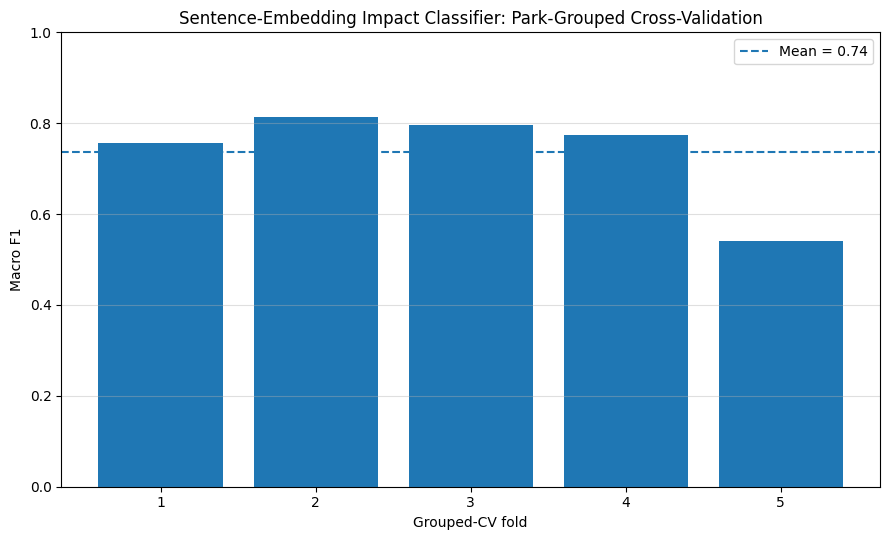

In [16]:
fig_grouped_cv, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(
    grouped_cv_folds_df["fold"].astype(str),
    grouped_cv_folds_df["macro_f1"],
)

mean_macro_f1 = grouped_cv_folds_df["macro_f1"].mean()
ax.axhline(
    mean_macro_f1,
    linestyle="--",
    label=f"Mean = {mean_macro_f1:.2f}",
)

ax.set_xlabel("Grouped-CV fold")
ax.set_ylabel("Macro F1")
ax.set_title(
    "Sentence-Embedding Impact Classifier: "
    "Park-Grouped Cross-Validation"
)
ax.set_ylim(0, 1)
ax.grid(axis="y", linewidth=0.8, alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

## 15. Summary

In [17]:
selected_test_metrics = embedding_metrics_df.loc[
    embedding_metrics_df["partition"].eq("test")
].set_index("evaluation_setting")

heldout_row = selected_test_metrics.loc["Held-out parks"]
mixed_row = selected_test_metrics.loc["Mixed parks"]
cv_macro_mean = grouped_cv_folds_df["macro_f1"].mean()
cv_macro_sd = grouped_cv_folds_df["macro_f1"].std(ddof=1)

rare_support = int(
    selected_heldout_class_metrics.loc[
        selected_heldout_class_metrics["impact_label"].eq(
            "informational_minimal_impact"
        ),
        "support",
    ].iloc[0]
)

report_summary = f"""
Secondary impact-label analysis:
- Held-out parks: accuracy = {heldout_row['accuracy']:.3f},
  Macro F1 = {heldout_row['macro_f1']:.3f},
  weighted F1 = {heldout_row['weighted_f1']:.3f}.
- Mixed parks: accuracy = {mixed_row['accuracy']:.3f},
  Macro F1 = {mixed_row['macro_f1']:.3f},
  weighted F1 = {mixed_row['weighted_f1']:.3f}.
- Five-fold park-grouped CV Macro F1:
  mean = {cv_macro_mean:.3f}, SD = {cv_macro_sd:.3f}.
- The fixed held-out test contains only {rare_support}
  informational/minimal-impact examples, so that class's individual
  score should be interpreted cautiously.
"""

print(report_summary)


Secondary impact-label analysis:
- Held-out parks: accuracy = 0.733,
  Macro F1 = 0.619,
  weighted F1 = 0.733.
- Mixed parks: accuracy = 0.778,
  Macro F1 = 0.698,
  weighted F1 = 0.786.
- Five-fold park-grouped CV Macro F1:
  mean = 0.736, SD = 0.112.
- The fixed held-out test contains only 3
  informational/minimal-impact examples, so that class's individual
  score should be interpreted cautiously.



## 16. Export tables, predictions, figures, and a zip archive

In [18]:
# Tables
all_metrics_df.to_csv(
    OUTPUT_DIR / "impact_overall_metrics.csv",
    index=False,
)
all_class_metrics_df.to_csv(
    OUTPUT_DIR / "impact_per_class_metrics.csv",
    index=False,
)
all_predictions_df.to_csv(
    OUTPUT_DIR / "impact_predictions.csv",
    index=False,
)
embedding_validation_df.to_csv(
    OUTPUT_DIR / "impact_embedding_validation_selection.csv",
    index=False,
)
generalization_gap_df.to_csv(
    OUTPUT_DIR / "impact_generalization_gap.csv",
    index=False,
)
selected_heldout_errors.to_csv(
    OUTPUT_DIR / "impact_heldout_errors.csv",
    index=False,
)
confusion_pairs_df.to_csv(
    OUTPUT_DIR / "impact_confusion_pairs.csv",
    index=False,
)
grouped_cv_folds_df.to_csv(
    OUTPUT_DIR / "impact_grouped_cv_folds.csv",
    index=False,
)
grouped_cv_summary_df.to_csv(
    OUTPUT_DIR / "impact_grouped_cv_summary.csv",
    index=False,
)

with pd.ExcelWriter(
    OUTPUT_DIR / "impact_analysis_results_summary.xlsx",
    engine="openpyxl",
) as writer:
    all_metrics_df.to_excel(
        writer,
        sheet_name="Overall_Metrics",
        index=False,
    )
    all_class_metrics_df.to_excel(
        writer,
        sheet_name="Per_Class_Metrics",
        index=False,
    )
    embedding_validation_df.to_excel(
        writer,
        sheet_name="Embedding_Selection",
        index=False,
    )
    generalization_gap_df.to_excel(
        writer,
        sheet_name="Generalization_Gap",
        index=False,
    )
    selected_heldout_errors.to_excel(
        writer,
        sheet_name="Heldout_Errors",
        index=False,
    )
    grouped_cv_folds_df.to_excel(
        writer,
        sheet_name="Grouped_CV_Folds",
        index=False,
    )
    grouped_cv_summary_df.to_excel(
        writer,
        sheet_name="Grouped_CV_Summary",
        index=False,
    )

# Figures
fig_model_comparison.savefig(
    OUTPUT_DIR / "figure_1_impact_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
fig_confusion.savefig(
    OUTPUT_DIR / "figure_2_impact_heldout_confusion.png",
    dpi=300,
    bbox_inches="tight",
)
fig_per_class.savefig(
    OUTPUT_DIR / "figure_3_impact_per_class_f1.png",
    dpi=300,
    bbox_inches="tight",
)
fig_grouped_cv.savefig(
    OUTPUT_DIR / "figure_4_impact_grouped_cv.png",
    dpi=300,
    bbox_inches="tight",
)

analysis_summary = {
    "target": "impact_label",
    "impact_labels": IMPACT_LABELS,
    "embedding_model": EMBEDDING_MODEL_NAME,
    "selected_C": best_C,
    "primary_evaluation": "held-out parks",
    "secondary_evaluation": "mixed parks",
    "heldout_test_metrics": {
        "accuracy": float(heldout_row["accuracy"]),
        "macro_f1": float(heldout_row["macro_f1"]),
        "weighted_f1": float(heldout_row["weighted_f1"]),
    },
    "mixed_test_metrics": {
        "accuracy": float(mixed_row["accuracy"]),
        "macro_f1": float(mixed_row["macro_f1"]),
        "weighted_f1": float(mixed_row["weighted_f1"]),
    },
    "grouped_cv_macro_f1_mean": float(cv_macro_mean),
    "grouped_cv_macro_f1_sd": float(cv_macro_sd),
    "heldout_informational_support": rare_support,
    "single_annotator_limitation": True,
}

with open(
    OUTPUT_DIR / "impact_analysis_summary.json",
    "w",
) as file:
    json.dump(analysis_summary, file, indent=2)

zip_path = Path(
    shutil.make_archive(
        str(OUTPUT_DIR),
        "zip",
        root_dir=OUTPUT_DIR,
    )
)

print("Saved outputs to:", OUTPUT_DIR.resolve())
print("Created zip archive:", zip_path)

for file_path in sorted(OUTPUT_DIR.iterdir()):
    print("-", file_path.name)

try:
    from google.colab import files
    print(
        "\nOptional Colab download command:\n"
        f"files.download({str(zip_path)!r})"
    )
except ImportError:
    pass

Saved outputs to: /content/nps_impact_outputs
Created zip archive: /content/nps_impact_outputs.zip
- figure_1_impact_model_comparison.png
- figure_2_impact_heldout_confusion.png
- figure_3_impact_per_class_f1.png
- figure_4_impact_grouped_cv.png
- impact_analysis_results_summary.xlsx
- impact_analysis_summary.json
- impact_confusion_pairs.csv
- impact_embedding_validation_selection.csv
- impact_generalization_gap.csv
- impact_grouped_cv_folds.csv
- impact_grouped_cv_summary.csv
- impact_heldout_errors.csv
- impact_overall_metrics.csv
- impact_per_class_metrics.csv
- impact_predictions.csv

Optional Colab download command:
files.download('/content/nps_impact_outputs.zip')
